In [1]:
import sys
sys.path.append("..")

In [2]:
%load_ext autoreload
%autoreload 2

w1**2/(1 - w1)
w1**2/(1 - w1)**2 + 2*w1/(1 - w1)


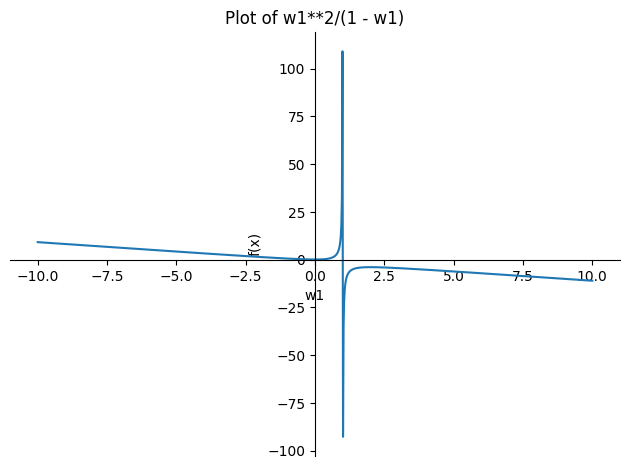

In [3]:

from sympy import symbols
from partialDerivator import compute_partial_derivative, plot_function
from variationalInference import bernoulli_dist

x = 2
w = symbols('w1')
f = bernoulli_dist(x,w)
print(f)
partial_deriv = compute_partial_derivative(f, w)
print(partial_deriv)
plot_function(f, w, (-10, 10))

In [4]:
from partialDerivatives.partialDerivator import compute_partial_derivative, plot_function
from sympy import symbols
import numpy as np


x = np.array([2,2])
w = [symbols('w1'), symbols('w2')]
f = w[0]**x[0] + w[1]**x[1]

partial_deriv = compute_partial_derivative(f, w)
plot_function(f, x, (-10, 10))

ModuleNotFoundError: No module named 'partialDerivatives'

## Using Variational Inference Loss

In this experiment, i'm trying to appproximate – in a unsupervised way – a normal distribution using variational inference loss  

In [34]:
from sympy.stats import Normal, sample
from sympy import symbols, Eq, Or
import numpy as np
from sympy.stats import P, Die

truth_mu = 2
truth_sigma = 1
x = Normal('x', truth_mu, truth_sigma)
num_samples = 100
samples_list = list(sample(x, size=num_samples))
samples_list = np.array(samples_list)

x_bold_train, x_bold_eval, x_bold_test = np.split(samples_list, [int(.6 * len(samples_list)), int(.8 * len(samples_list))]) 

In [43]:
from univariateGaussianVariationalModel import UnivariateGaussianVariationalModel


model = UnivariateGaussianVariationalModel()
model.fit(x_bold_train=x_bold_train, x_bold_val=x_bold_eval, learning_rate=0.01, epochs=200, patience=30)
mu_est, sigma_est = model.get_parameters()
print("Estimated mu:", mu_est)
print("Estimated sigma:", sigma_est)

TypeError: 'Add' object cannot be interpreted as an integer

In [11]:
import numpy as np
from sympy import symbols, exp, sqrt, pi, log, lambdify
from partialDerivator import cost_function, gradient_descent, compute_loglikelihood, get_normal_density_value

x, mu, sigma = symbols('x mu sigma', real=True)
def normal_density(x, mu, sigma):
    coeff = 1 / (sqrt(2 * pi) * sigma)
    exponent = exp(-(x - mu)**2 / (2 * sigma**2))
    return coeff * exponent
normal_dist = (1 / (sqrt(2*pi)*sigma)) * exp(-(x - mu)**2 / (2*sigma**2))

logpdf = log(normal_dist)

logpdf_func = lambdify(
    (x, mu, sigma),
    logpdf,
    'numpy'
)

mu_true = 2
sigma = 1
n = 500

x_samples = np.random.normal(mu_true, sigma, n)
x_samples = samples_list

mu_1 = 2
mu_2 = 7

logL_mu2 = np.sum(logpdf_func(x_samples, mu_1, sigma))
logL_mu7 = np.sum(logpdf_func(x_samples, mu_2, sigma))

normal_dist1 = normal_dist.subs({sigma:1, mu:mu_1})
normal_dist2 = normal_dist.subs({sigma:1, mu:mu_2})

print( compute_loglikelihood(x_samples, normal_density(x_samples,mu,sigma), ({'mu':mu_1, 'sigma':1})))
print( compute_loglikelihood(x_samples, normal_density(x_samples,mu,sigma), ({'mu':mu_2, 'sigma':1})))

print("log L(mu=2):", logL_mu2)
print("log L(mu=7):", logL_mu7)
print("Diferença:", logL_mu2 - logL_mu7)

print(get_normal_density_value(x_samples[1], sigma, mu_1))
print(get_normal_density_value(x_samples[1], sigma, mu_2))

-64.49673801841948
-651.1978195239116
log L(mu=2): -64.49673801841948
log L(mu=7): -651.1978195239116
Diferença: 586.7010815054921
0.3623770039870231
1.5077730743195155e-07


In [6]:

class A:
    def __init__(self):
        self.a= 10
        self.b = 2
        
    def method1(self):
        z = {'a': 7, 'b': 13}
        
        print("Method 1 called")
        for param in z:
            print(param, z[param])
            self.__dict__[param]= z[param]



z = {'a': 10, 'b': 20}
#print(sum(**z, b=4))

a = A()
a.method1()
print(a.a)
print(a.b)

# for param in z:
#     #print(param, z[param])  
#     #print(param[0])
#     #print(z[param])


Method 1 called
a 7
b 13
7
13


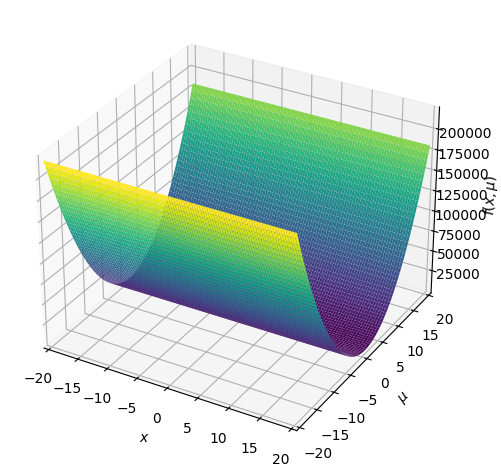

KeyboardInterrupt: 

In [59]:
import sympy as sp
from sympy import Array
from sympy.plotting import plot3d,  plot
from partialDerivator import cost_function, gradient_descent, cost_function

x, sigma, mu = sp.symbols('x sigma mu')
f = cost_function(x_bold=samples_list, mu=mu, sigma=1)
plot3d(f, (x, -20, 20), (mu, -20, 20))
x_bold = samples_list
best_mu = gradient_descent(func=f, var=mu, datapoints=x_bold, learning_rate=0.01, iterations=100)

print(f"Best mu: {best_mu}")
initial_loss = cost_function(x_bold=samples_list, mu=0, sigma=1)
final_loss = cost_function(x_bold=samples_list, mu=best_mu, sigma=1)
print(f"Initial loss: {float(initial_loss)}, Final loss: {float(final_loss)}")







Best mu: 0.904610278102844
Initial loss: 89.28870502863468, Final loss: 64.73911237115551